# 06. Latent Space Arithmetic — TensorFlow

학습된 VAE의 잠재 공간에서 벡터 연산으로 이미지 속성을 제어합니다.

| 연산 | 수식 | 의미 |
|------|------|---------|
| 기본 산술 | `z_A - z_B + z_C` | B의 특성을 A에서 빼고 C에 더함 |
| 방향 벡터 | `mean(그룹A) - mean(그룹B)` | 두 그룹의 차이 방향 추출 |
| 속성 이식 | `z_target + α × 방향벡터` | 강도(α) 조절로 속성 적용 |

## 1. 환경 설정

In [230]:
import os, json, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# CWD 고정
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

DEVICE = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: /GPU:0


## 2. 모델 로드

In [231]:
CKPT_DIR = Path('checkpoints_tf')

with open(CKPT_DIR / 'config.json') as f:
    CFG = json.load(f)

IMG_SIZE   = CFG['img_size']
CHANNELS   = CFG['channels']
BASE_CH    = CFG['base_channels']
LATENT_DIM = CFG['latent_dim']
print(f'latent_dim={LATENT_DIM}  base_ch={BASE_CH}')


def build_encoder(img_size=64, channels=4, base_ch=32, latent_dim=128):
    inp = tf.keras.Input(shape=(img_size, img_size, channels))
    x = inp; ch = base_ch
    for i in range(4):
        x = tf.keras.layers.Conv2D(ch, 4, strides=2, padding='same')(x)
        x = tf.keras.layers.BatchNormalization(momentum=0.9)(x)
        x = tf.keras.layers.LeakyReLU(0.2)(x)
        ch *= 2
    x = tf.keras.layers.Flatten()(x)
    return tf.keras.Model(inp, [
        tf.keras.layers.Dense(latent_dim, name='mu')(x),
        tf.keras.layers.Dense(latent_dim, name='log_var')(x),
    ], name='encoder')


def build_decoder(img_size=64, channels=4, base_ch=32, latent_dim=128):
    start_ch = base_ch * 8
    start_sp = img_size // 16
    inp = tf.keras.Input(shape=(latent_dim,))
    x = tf.keras.layers.Dense(start_sp * start_sp * start_ch)(inp)
    x = tf.keras.layers.Reshape((start_sp, start_sp, start_ch))(x)
    for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
        x = tf.keras.layers.Conv2DTranspose(out_ch, 4, strides=2, padding='same')(x)
        if i < 3:
            x = tf.keras.layers.BatchNormalization(momentum=0.9)(x)
            x = tf.keras.layers.ReLU()(x)
        else:
            x = tf.keras.layers.Activation('sigmoid')(x)
    return tf.keras.Model(inp, x, name='decoder')


class VAE(tf.keras.Model):
    def __init__(self, img_size, channels, base_ch, latent_dim, beta=1.0):
        super().__init__()
        self.encoder = build_encoder(img_size, channels, base_ch, latent_dim)
        self.decoder = build_decoder(img_size, channels, base_ch, latent_dim)

    def call(self, x, training=False):
        mu, lv = self.encoder(x, training=training)
        z = mu + tf.random.normal(tf.shape(mu)) * tf.exp(0.5 * lv)
        return self.decoder(z, training=training), mu, lv


with tf.device(DEVICE):
    model = VAE(IMG_SIZE, CHANNELS, BASE_CH, LATENT_DIM)
    _ = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, CHANNELS)))
    model.load_weights(str(CKPT_DIR / 'best.weights.h5'))
print('모델 로드 완료.')

latent_dim=128  base_ch=32
모델 로드 완료.


## 3. 이미지 로드 & 인코딩 유틸

In [232]:
BODY_DIR = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))
print(f'body 이미지: {len(all_paths):,}장')


def load_imgs(paths):
    """경로 리스트 → (N, 64, 64, 4) float32 텐서 [0,1]"""
    imgs = []
    for p in paths:
        raw = tf.io.read_file(str(p))
        img = tf.image.decode_png(raw, channels=4)
        imgs.append(tf.cast(img, tf.float32) / 255.0)
    return tf.stack(imgs)


def encode(imgs):
    """이미지 텐서 → μ 벡터 (결정론적, 재현성 보장)"""
    mu, _ = model.encoder(imgs, training=False)
    return mu


def decode(z):
    """잠재 벡터 → 이미지 텐서"""
    return model.decoder(z, training=False)


BG = np.array([0.82, 0.82, 0.82])

def composite(tensor):
    """RGBA 텐서 → RGB numpy (알파 합성)"""
    arr   = np.array(tensor)
    alpha = arr[:, :, 3:4]
    return np.clip(arr[:, :, :3] * alpha + BG * (1 - alpha), 0, 1)


def show_row(images, labels=None, title=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.8))
    if n == 1: axes = [axes]
    for ax, img, lbl in zip(axes, images, labels or [''] * n):
        ax.imshow(composite(img))
        ax.set_title(lbl, fontsize=7)
        ax.axis('off')
    if title: plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


print('유틸 함수 정의 완료.')

body 이미지: 4,544장
유틸 함수 정의 완료.


## 4. 기본 산술 — z_A - z_B + z_C

A의 특성에서 B의 특성을 빼고 C의 특성을 더합니다.

In [233]:
# ── 이미지 선택 ────────────────────────────────────────
# 파일명으로 검색하거나 인덱스로 직접 지정
def find(keyword):
    return [p for p in all_paths if keyword in p.name]

# 예시: 키워드로 이미지 찾기
# candidates = find('walk')
# print([p.name for p in candidates[:5]])

import time
random.seed(time.time())
sample = random.sample(all_paths, 3)
path_A, path_B, path_C = sample

print(f'A: {path_A.name}')
print(f'B: {path_B.name}')
print(f'C: {path_C.name}')

A: bodies_male_halfslash_1_4.png
B: bodies_muscular_walk_1_6_flip.png
C: bodies_pregnant_run_1_1.png


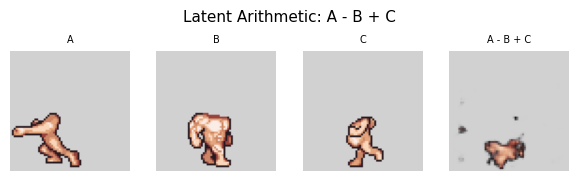

In [234]:
imgs_ABC = load_imgs([path_A, path_B, path_C])
z_A, z_B, z_C = encode(imgs_ABC)

# z_A - z_B + z_C
z_result = z_A - z_B + z_C
img_result = decode(tf.stack([z_result]))

show_row(
    [imgs_ABC[0], imgs_ABC[1], imgs_ABC[2], img_result[0]],
    labels=['A', 'B', 'C', 'A - B + C'],
    title='Latent Arithmetic: A - B + C'
)

## 5. 방향 벡터 추출

두 그룹의 평균 잠재 벡터 차이로 속성 방향을 추출합니다.

```
방향벡터 = mean(그룹A의 z) - mean(그룹B의 z)
```

사용 가능한 키워드 목록을 확인한 뒤 `KEYWORD_A`, `KEYWORD_B`를 설정하세요.

In [235]:
# 파일명 토큰을 분석해 사용 가능한 키워드와 빈도를 출력합니다.
from collections import Counter

# 숫자·flip·bodies 등 의미 없는 토큰 제외
EXCLUDE = {'bodies', 'flip', 'body'}

tokens = Counter()
for p in all_paths:
    parts = p.stem.split('_')
    for part in parts:
        if not part.isdigit() and part not in EXCLUDE:
            tokens[part] += 1

# 빈도순 정렬 출력
print(f"{'키워드':>20}  {'파일 수':>8}")
print('-' * 33)
for token, count in tokens.most_common():
    print(f'{token:>20}  {count:>8,}')

                 키워드      파일 수
---------------------------------
              female       916
                male       916
                teen       916
                walk       864
            pregnant       764
            muscular       608
               slash       576
                jump       480
               child       424
               shoot       416
                 run       320
              thrust       320
           backslash       312
                 sit       288
           spellcast       280
                idle       256
                hurt       144
           halfslash       144
               emote        96
              combat        64
               climb        48


In [236]:
# ── 그룹 설정 ───────────────────────────────────────────
# 파일명 키워드로 두 그룹을 나눕니다.
# 예: 애니메이션 프레임 번호, 캐릭터 타입, 색상 계열 등
#
# 아래는 예시입니다. 실제 파일명에 맞게 키워드를 수정하세요.

KEYWORD_A = 'sit'    # 그룹 A 키워드
KEYWORD_B = 'shoot'  # 그룹 B 키워드

group_A_paths = find(KEYWORD_A)[:50]
group_B_paths = find(KEYWORD_B)[:50]

print(f'그룹 A ({KEYWORD_A}): {len(group_A_paths)}장')
print(f'그룹 B ({KEYWORD_B}): {len(group_B_paths)}장')

if not group_A_paths or not group_B_paths:
    print('\n키워드에 해당하는 파일이 없습니다. KEYWORD_A / KEYWORD_B를 수정하세요.')
    print('파일명 예시:', [p.name for p in random.sample(all_paths, 5)])

그룹 A (sit): 50장
그룹 B (shoot): 50장


방향 벡터 norm: 2.3182


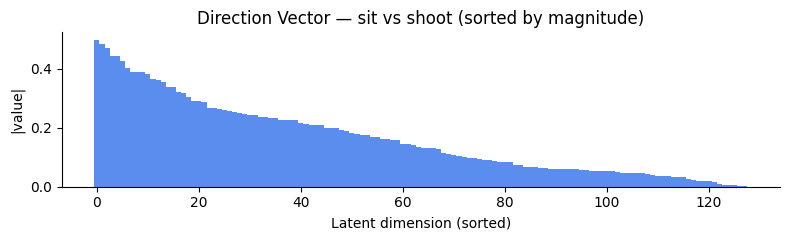

In [237]:
imgs_A = load_imgs(group_A_paths)
imgs_B = load_imgs(group_B_paths)

z_A_mean = tf.reduce_mean(encode(imgs_A), axis=0)
z_B_mean = tf.reduce_mean(encode(imgs_B), axis=0)
direction = z_A_mean - z_B_mean

print(f'방향 벡터 norm: {tf.norm(direction).numpy():.4f}')

# 방향 벡터 크기 분포 시각화
plt.figure(figsize=(8, 2.5))
plt.bar(range(len(direction)), np.sort(np.abs(direction.numpy()))[::-1],
        color='#5b8dee', width=1.0)
plt.title(f'Direction Vector — {KEYWORD_A} vs {KEYWORD_B} (sorted by magnitude)')
plt.xlabel('Latent dimension (sorted)'); plt.ylabel('|value|')
for spine in ['top', 'right']: plt.gca().spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

## 6. 속성 이식 — 강도(α) 조절

방향 벡터를 대상 이미지의 잠재 벡터에 더해 속성을 이식합니다.

```
z_결과 = z_대상 + α × 방향벡터
```

- **α = 0** : 원본 유지
- **α > 0** : 그룹 A 방향으로 속성 이동
- **α < 0** : 그룹 B 방향으로 속성 이동
- α 절댓값이 클수록 속성 변화 강도가 세짐

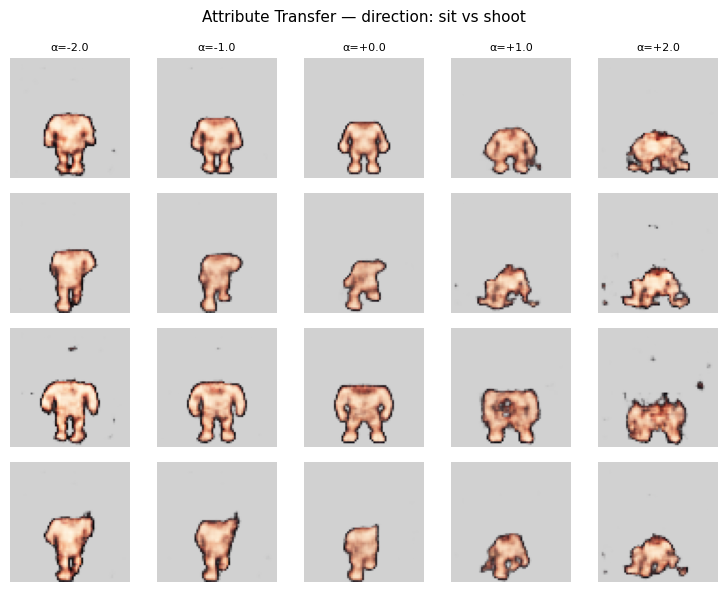

In [238]:
# 적용할 대상 이미지 선택
target_paths = random.sample(all_paths, 4)
target_imgs  = load_imgs(target_paths)
z_targets    = encode(target_imgs)

# α 범위 설정
alphas = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(len(target_paths), len(alphas),
                         figsize=(len(alphas) * 1.5, len(target_paths) * 1.5))
axes = np.array(axes).reshape(len(target_paths), len(alphas))

for row, z_t in enumerate(z_targets):
    for col, alpha in enumerate(alphas):
        z_mod  = z_t + alpha * direction
        img_out = decode(tf.expand_dims(z_mod, 0))
        axes[row, col].imshow(composite(img_out[0]))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'α={alpha:+.1f}', fontsize=8)

plt.suptitle(f'Attribute Transfer — direction: {KEYWORD_A} vs {KEYWORD_B}', fontsize=11)
plt.tight_layout()
plt.show()

## 7. 여러 방향 벡터 합성

`DIRECTIONS` 리스트에 `(키워드A, 키워드B, alpha)` 튜플을 원하는 만큼 추가해 N개의 방향벡터를 동시에 합성합니다.

```
z_결과 = z_대상 + α1×dir1 + α2×dir2 + α3×dir3 + ...
```

- 튜플을 추가/제거하는 것만으로 합성 벡터 수를 자유롭게 조절
- 각 방향벡터의 `alpha`를 독립적으로 설정 가능
- 결과는 벡터가 누적 적용되는 과정을 단계별로 시각화

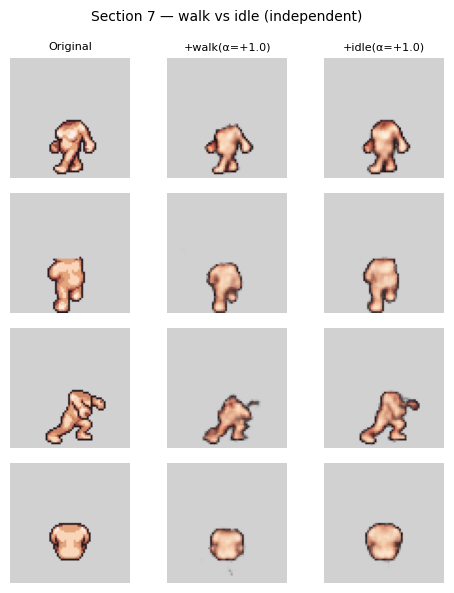

In [239]:
# 섹션 5와 독립적으로 동작합니다.
# KEYWORD_C, KEYWORD_D 각각을 전체 평균 z와의 차이로 방향벡터를 구해
# 오리지널에 개별 적용한 결과를 나란히 비교합니다.

KEYWORD_C = 'walk'
KEYWORD_D = 'idle'
alpha_C   = 1.0
alpha_D   = 1.0

group_C = find(KEYWORD_C)[:50]
group_D = find(KEYWORD_D)[:50]

if not group_C or not group_D:
    print('키워드에 해당하는 파일이 없습니다. KEYWORD_C / KEYWORD_D를 수정하세요.')
else:
    # 전체 평균 z (기준점)
    import random as _random
    sample_all = _random.sample(list(all_paths), min(200, len(all_paths)))
    z_mean_all = tf.reduce_mean(encode(load_imgs(sample_all)), axis=0)

    # 각 키워드의 방향벡터 = 그룹 평균 - 전체 평균
    dir_C = tf.reduce_mean(encode(load_imgs(group_C)), axis=0) - z_mean_all
    dir_D = tf.reduce_mean(encode(load_imgs(group_D)), axis=0) - z_mean_all

    t_imgs = load_imgs(random.sample(all_paths, 4))
    z_ts   = encode(t_imgs)

    fig, axes = plt.subplots(len(t_imgs), 3, figsize=(5, len(t_imgs) * 1.5))
    axes = np.array(axes).reshape(len(t_imgs), 3)

    for row, (z_t, orig) in enumerate(zip(z_ts, t_imgs)):
        res_C = decode(tf.expand_dims(z_t + alpha_C * dir_C, 0))
        res_D = decode(tf.expand_dims(z_t + alpha_D * dir_D, 0))
        axes[row, 0].imshow(composite(orig));       axes[row, 0].axis('off')
        axes[row, 1].imshow(composite(res_C[0]));   axes[row, 1].axis('off')
        axes[row, 2].imshow(composite(res_D[0]));   axes[row, 2].axis('off')
        if row == 0:
            axes[row, 0].set_title('Original',                   fontsize=8)
            axes[row, 1].set_title(f'+{KEYWORD_C}(α={alpha_C:+.1f})', fontsize=8)
            axes[row, 2].set_title(f'+{KEYWORD_D}(α={alpha_D:+.1f})', fontsize=8)

    plt.suptitle(f'Section 7 — {KEYWORD_C} vs {KEYWORD_D} (independent)', fontsize=10)
    plt.tight_layout(); plt.show()